<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS LePhare Physical Baryonic Burden V8 — download/reproduction notebook

This notebook is a clean V8 continuation of the KiDS PneE weak-lensing programme.

**Purpose:** replace the V7 fallback baryonic burden proxy with a physical stellar-mass burden derived from the KiDS DR4 bright-galaxy LePhare catalogue.

Expected local/Drive catalogue path:

```text
/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits
```

The working ECSM projection chain is:

```text
KiDS PneE bandpower
+ NZ_LENS/NZ_SOURCE lens-source geometry
+ LePhare stellar-mass burden by lens redshift bin
+ domain-boundary-gradient term
+ finite-response kernel
→ predicted P_gκ^E(ℓ)
```

Guardrail: this is a physical-baryonic-burden bridge test. It uses stellar mass binned by the two KiDS lens-bin redshift ranges, not a full 3D baryonic mass map or individual lens-galaxy projection integral.

In [4]:
# CELL 01 — SETUP
import os, sys, json, math, re, glob, shutil, zipfile, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def banner(txt):
    print("\n" + "="*72)
    print(txt)
    print("="*72)

OUT = Path("/content/ecsm_kids_lephare_physical_baryonic_burden_v8_out")
DATA = OUT / "data"
TAB = OUT / "tables"
FIG = OUT / "figures"
for p in [OUT, DATA, TAB, FIG]:
    p.mkdir(parents=True, exist_ok=True)

LEPHARE_PATH = Path("/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits")
print("Output:", OUT)
print("Expected LePhare:", LEPHARE_PATH)

Output: /content/ecsm_kids_lephare_physical_baryonic_burden_v8_out
Expected LePhare: /content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits


In [5]:
# CELL 02 — INSTALL / IMPORT FITS TOOLS AND DOWNLOAD KiDS CAT_TO_OBS REPOSITORY
banner("CELL 02 — INSTALL / IMPORT FITS TOOLS AND DOWNLOAD KiDS CAT_TO_OBS REPOSITORY")

try:
    from astropy.io import fits
except Exception:
    !pip -q install astropy
    from astropy.io import fits


def table_to_df(data):
    if data is None:
        return pd.DataFrame()
    df = pd.DataFrame(np.array(data))
    for c in df.columns:
        try:
            if df[c].dtype.byteorder == ">":
                df[c] = df[c].values.byteswap().newbyteorder()
        except Exception:
            pass
    return df

repo_zip = DATA / "Cat_to_Obs_K1000_P1_master.zip"
repo_dir = DATA / "Cat_to_Obs_K1000_P1_repo"
repo_dir.mkdir(parents=True, exist_ok=True)
url = "https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip"

if not any(repo_dir.glob("Cat_to_Obs_K1000_P1-master/**/bp_KIDS1000*.fits")):
    print("Downloading:", url)
    import urllib.request
    urllib.request.urlretrieve(url, repo_zip)
    with zipfile.ZipFile(repo_zip, "r") as z:
        z.extractall(repo_dir)
else:
    print("Repository already present.")

roots = list(repo_dir.glob("Cat_to_Obs_K1000_P1-master"))
if not roots:
    raise RuntimeError("Could not find extracted Cat_to_Obs_K1000_P1-master directory.")
REPO = roots[0]
print("Repository root:", REPO)


CELL 02 — INSTALL / IMPORT FITS TOOLS AND DOWNLOAD KiDS CAT_TO_OBS REPOSITORY
Repository already present.
Repository root: /content/ecsm_kids_lephare_physical_baryonic_burden_v8_out/data/Cat_to_Obs_K1000_P1_repo/Cat_to_Obs_K1000_P1-master


In [6]:
# CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
banner("CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE")

from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits

def native_array(a):
    """
    Convert FITS big-endian arrays to native-endian arrays for Pandas/Numpy.
    Required for Colab/Python 3.12 where Pandas may raise:
    ValueError: Big-endian buffer not supported on little-endian compiler
    """
    arr = np.asarray(a)
    if arr.dtype.byteorder in (">", "<"):
        return arr.byteswap().view(arr.dtype.newbyteorder("="))
    return arr

def fits_table_to_native_df(data):
    """
    Convert a FITS binary table to a safe Pandas DataFrame.
    Handles big-endian scalar columns.
    """
    out = {}
    names = list(data.names)
    for name in names:
        col = data[name]
        out[name] = native_array(col)
    return pd.DataFrame(out)

def hdu_names(path):
    try:
        with fits.open(path, memmap=True) as hdul:
            return [h.name for h in hdul]
    except Exception:
        return []

# Search for correct KiDS bandpower file
search_roots = [
    OUT,
    OUT / "data",
    Path("/content"),
]

fits_files = []
for root in search_roots:
    if Path(root).exists():
        fits_files.extend(Path(root).rglob("*.fits"))

fits_files = sorted(set(fits_files))
print("FITS files found:", len(fits_files))

candidates = []
for p in fits_files:
    names = hdu_names(p)
    score = 0
    base = p.name.lower()

    if "bp_kids1000" in base:
        score += 10
    if "blindc" in base:
        score += 5
    if "no_m_bias" in base:
        score += 3
    if "pnee" in [n.lower() for n in names]:
        score += 10
    if "covmat" in [n.lower() for n in names]:
        score += 3
    if "nz_lens" in [n.lower() for n in names]:
        score += 3
    if "nz_source" in [n.lower() for n in names]:
        score += 3
    if "cosebis" in base:
        score -= 5
    if "xipm" in base:
        score -= 5

    if score > 0:
        candidates.append((score, p, names))

candidates = sorted(candidates, key=lambda x: x[0], reverse=True)

print("Top candidates:")
for score, p, names in candidates[:10]:
    print(f"score {score:2d} | {p.name} | {names}")

if not candidates:
    raise FileNotFoundError("No suitable KiDS PneE FITS file found.")

FITS_PATH = candidates[0][1]
print("Using FITS:", FITS_PATH)

with fits.open(FITS_PATH, memmap=True) as hdul:
    hdul.info()

    pne_df = fits_table_to_native_df(hdul["PneE"].data)
    nz_lens = fits_table_to_native_df(hdul["NZ_LENS"].data)
    nz_source = fits_table_to_native_df(hdul["NZ_SOURCE"].data)

    cov_full = native_array(hdul["COVMAT"].data).astype(float)

# Standardize PneE column names
rename_map = {}
for c in pne_df.columns:
    cu = str(c).upper()
    if cu == "BIN1":
        rename_map[c] = "lens_bin"
    elif cu == "BIN2":
        rename_map[c] = "source_bin"
    elif cu == "ANGBIN":
        rename_map[c] = "ell_bin"
    elif cu == "VALUE":
        rename_map[c] = "Pgk_E"
    elif cu == "ANG":
        rename_map[c] = "ell"

pne_df = pne_df.rename(columns=rename_map)

required = ["lens_bin", "source_bin", "ell_bin", "Pgk_E", "ell"]
missing = [c for c in required if c not in pne_df.columns]
if missing:
    raise KeyError(
        f"PneE table missing expected columns after rename: {missing}; "
        f"columns={list(pne_df.columns)}"
    )

# Critical: copy after native-endian conversion
vec = pne_df.loc[:, required].copy()

for c in required:
    vec[c] = pd.to_numeric(vec[c], errors="coerce")

vec = vec.dropna().reset_index(drop=True)
vec["lens_bin"] = vec["lens_bin"].astype(int)
vec["source_bin"] = vec["source_bin"].astype(int)
vec["ell_bin"] = vec["ell_bin"].astype(int)
vec["vec_index"] = np.arange(len(vec), dtype=int)

N = len(vec)

# COVMAT is 200x200; PneE is first 80 rows/cols for this file
C = np.asarray(cov_full[:N, :N], dtype=float)
vec["sigma_diag"] = np.sqrt(np.clip(np.diag(C), 0, np.inf))

# Lens redshift edges for KiDS/BOSS/2dFLenS lens bins
lens_z_edges = {
    1: (0.2, 0.5),
    2: (0.5, 0.75),
}

vec["lens_z_min"] = vec["lens_bin"].map(lambda b: lens_z_edges.get(int(b), (np.nan, np.nan))[0])
vec["lens_z_max"] = vec["lens_bin"].map(lambda b: lens_z_edges.get(int(b), (np.nan, np.nan))[1])
vec["lens_z_eff_simple"] = 0.5 * (vec["lens_z_min"] + vec["lens_z_max"])

print("N:", N, "Covariance:", C.shape)
display(vec.head())

block_manifest = (
    vec.groupby(["lens_bin", "source_bin"])
    .agg(
        N_ell=("ell", "size"),
        ell_min=("ell", "min"),
        ell_max=("ell", "max"),
        mean_abs_Pgk=("Pgk_E", lambda x: float(np.mean(np.abs(x)))),
        mean_sigma_diag=("sigma_diag", "mean"),
    )
    .reset_index()
)

display(block_manifest)

# Save extracted tables
vec.to_csv(TAB / "v8_pnee_vector.csv", index=False)
block_manifest.to_csv(TAB / "v8_block_manifest.csv", index=False)
nz_lens.to_csv(TAB / "v8_nz_lens.csv", index=False)
nz_source.to_csv(TAB / "v8_nz_source.csv", index=False)

print("Saved extracted data tables.")


CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
FITS files found: 29
Top candidates:
score 37 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 37 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 34 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 34 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 34 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMA

,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35


,lens_bin,source_bin,N_ell,ell_min,ell_max,mean_abs_Pgk,mean_sigma_diag
0,1,1,8,118.441992,1266.44273,0.001464,0.001625
1,1,2,8,118.441992,1266.44273,0.001841,0.001092
2,1,3,8,118.441992,1266.44273,0.004462,0.000924
3,1,4,8,118.441992,1266.44273,0.009105,0.001053
4,1,5,8,118.441992,1266.44273,0.011178,0.001090
5,2,1,8,118.441992,1266.44273,0.001909,0.001574
6,2,2,8,118.441992,1266.44273,0.000889,0.001060
7,2,3,8,118.441992,1266.44273,0.000889,0.000887
8,2,4,8,118.441992,1266.44273,0.003603,0.001011
9,2,5,8,118.441992,1266.44273,0.006633,0.001053


Saved extracted data tables.


In [7]:
# CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
banner("CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES")

if not LEPHARE_PATH.exists():
    from google.colab import drive
    drive.mount("/content/drive")
if not LEPHARE_PATH.exists():
    raise FileNotFoundError(f"LePhare catalogue not found at {LEPHARE_PATH}. Upload/copy it there first.")

with fits.open(LEPHARE_PATH, memmap=True) as hdul:
    hdul.info()
    table_hdu = None
    for i, h in enumerate(hdul):
        if hasattr(h, "columns"):
            cols = list(h.columns.names)
            if any("MASS" in str(c).upper() for c in cols):
                table_hdu = i
                break
    if table_hdu is None:
        raise KeyError("Could not find a LePhare table HDU with MASS columns.")
    leph = table_to_df(hdul[table_hdu].data)

print("LePhare HDU:", table_hdu)
print("Rows:", len(leph), "Columns:", len(leph.columns))
print("Columns:", list(leph.columns)[:80])

def choose_col(cols, patterns):
    for pat in patterns:
        hits = [c for c in cols if re.search(pat, str(c), re.I)]
        if hits:
            return hits[0]
    return None

cols = list(leph.columns)
z_col = choose_col(cols, [r"^REDSHIFT$", r"ZPHOT", r"Z_PHOT", r"PHOTOZ", r"Z_BEST", r"ZBEST", r"^Z$"])
mass_col = choose_col(cols, [r"^MASS_BEST$", r"^MASS_MED$", r"STELLAR.*MASS", r"LOG.*MASS", r"MASS"])
ra_col = choose_col(cols, [r"^RAJ2000$", r"^RA$", r"ALPHA"])
dec_col = choose_col(cols, [r"^DECJ2000$", r"^DEC$", r"DELTA"])

print("Selected columns:", {"z_col": z_col, "mass_col": mass_col, "ra_col": ra_col, "dec_col": dec_col})
if z_col is None or mass_col is None:
    raise KeyError("Need a redshift and stellar-mass column from LePhare.")

leph_small = leph[[c for c in [ra_col, dec_col, z_col, mass_col] if c is not None]].copy()
leph_small = leph_small.rename(columns={z_col:"z", mass_col:"logM", ra_col:"ra", dec_col:"dec"})
leph_small["z"] = pd.to_numeric(leph_small["z"], errors="coerce")
leph_small["logM"] = pd.to_numeric(leph_small["logM"], errors="coerce")
leph_small = leph_small.replace([np.inf, -np.inf], np.nan).dropna(subset=["z","logM"])
leph_small = leph_small[(leph_small["z"] > 0) & (leph_small["z"] < 2.5)]
leph_small = leph_small[(leph_small["logM"] > 4.0) & (leph_small["logM"] < 13.5)]
leph_small["Mstar"] = 10 ** leph_small["logM"]

display(leph_small.head())
print("Usable LePhare rows:", len(leph_small))
leph_small.to_csv(TAB/"v8_lephare_stellar_mass_clean_sample.csv", index=False)

burden_rows = []
for lb, (zlo, zhi) in lens_z_edges.items():
    sub = leph_small[(leph_small["z"] >= zlo) & (leph_small["z"] < zhi)]
    if len(sub) == 0:
        continue
    burden_rows.append({
        "lens_bin": int(lb), "z_min": float(zlo), "z_max": float(zhi), "n_gal": int(len(sub)),
        "median_logM": float(np.nanmedian(sub["logM"])), "mean_logM": float(np.nanmean(sub["logM"])),
        "median_Mstar": float(np.nanmedian(sub["Mstar"])), "mean_Mstar": float(np.nanmean(sub["Mstar"])),
        "mass_col_used": str(mass_col), "redshift_col_used": str(z_col), "source_catalog": str(LEPHARE_PATH),
    })

baryon_df = pd.DataFrame(burden_rows)
if len(baryon_df) < len(lens_z_edges):
    print("WARNING: Did not construct physical burden for all lens bins.")
display(baryon_df)
baryon_df.to_csv(TAB/"v8_physical_stellar_mass_burden_by_lens_bin.csv", index=False)
mean_med = float(np.mean(baryon_df["median_Mstar"])) if len(baryon_df) else np.nan
physical_burden_norm = {int(r.lens_bin): float(r.median_Mstar/mean_med) for _, r in baryon_df.iterrows()}
print("physical_burden_norm:", physical_burden_norm)


CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
Mounted at /content/drive
Filename: /content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (5031,)   uint8   
  1  /dane/KiDS/DR4/photozs.DR4.1_bright_ugri+KV_masses.fits#1    1 BinTableHDU    101   1239422R x 39C   [30A, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, I, I, I, I, I, I, I, I, D, D, D, D, D, D, D, D, D]   
LePhare HDU: 1
Rows: 1239422 Columns: 39
Columns: ['ID', 'RAJ2000', 'DECJ2000', 'K_COR_u', 'K_COR_g', 'K_COR_r', 'K_COR_i', 'K_COR_Z', 'K_COR_Y', 'K_COR_J', 'K_COR_H', 'K_COR_Ks', 'MAG_ABS_u', 'MAG_ABS_g', 'MAG_ABS_r', 'MAG_ABS_i', 'MAG_ABS_Z', 'MAG_ABS_Y', 'MAG_ABS_J', 'MAG_ABS_H', 'MAG_ABS_Ks', 'MABS_FILTu', 'MABS_FILTg', 'MABS_FILTr', 'MABS_FILTi', 'MABS_FILTZ', 'MABS_FILTY', 'MABS_FILTJ', 'MABS_FILTH', 'MABS_FILTKs', 'CONTEXT', 'REDSHIFT', 'MASS_MED', 'MASS_INF', 'MASS_SUP',

,ra,dec,z,logM,Mstar
0,0.000015,-33.000297,0.086948,9.03873,1.093276e+09
1,0.000147,-34.465259,0.146714,9.79488,6.235625e+09
2,0.000532,-32.597583,0.203528,10.21470,1.639457e+10
3,0.000574,-33.637488,0.267514,9.56031,3.633373e+09
4,0.000598,-28.084937,0.319210,10.64370,4.402506e+10


Usable LePhare rows: 1239396


,lens_bin,z_min,z_max,n_gal,median_logM,mean_logM,median_Mstar,mean_Mstar,mass_col_used,redshift_col_used,source_catalog
0,1,0.2,0.50,748019,10.4995,10.418680,3.158639e+10,4.056480e+10,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...
1,2,0.5,0.75,13403,10.9820,10.938311,9.594006e+10,1.427320e+11,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...


physical_burden_norm: {1: 0.49537001278863535, 2: 1.5046299872113647}


In [8]:
# CELL 05 — GEOMETRY + DOMAIN BOUNDARY GRADIENT + PHYSICAL BARYONIC DRIVER
banner("CELL 05 — GEOMETRY + DOMAIN BOUNDARY GRADIENT + PHYSICAL BARYONIC DRIVER")

def normalize_nz(z, n):
    z = np.asarray(z, float); n = np.asarray(n, float)
    n = np.where(np.isfinite(n), np.maximum(n, 0), 0)
    area = np.trapezoid(n, z)
    return n/area if area > 0 else np.zeros_like(n)

def nz_moments(z, n):
    nn = normalize_nz(z, n)
    mu = np.trapezoid(z*nn, z)
    var = np.trapezoid((z-mu)**2*nn, z)
    return float(mu), float(np.sqrt(max(var, 1e-12)))

def get_z_col(df):
    for name in ["Z_MID", "z_mid", "Z_mid"]:
        if name in df.columns: return name
    for c in df.columns:
        if "MID" in str(c).upper(): return c
    raise KeyError("Could not find Z_MID column.")

def bin_cols(df):
    return [c for c in df.columns if re.match(r"BIN\d+", str(c), re.I)]

z_l_col = get_z_col(nz_lens); z_s_col = get_z_col(nz_source)
lens_cols = bin_cols(nz_lens); source_cols = bin_cols(nz_source)
z_l = pd.to_numeric(nz_lens[z_l_col], errors="coerce").to_numpy(float)
z_s = pd.to_numeric(nz_source[z_s_col], errors="coerce").to_numpy(float)

rows = []
for lb in sorted(vec.lens_bin.unique()):
    lcol = lens_cols[int(lb)-1] if int(lb)-1 < len(lens_cols) else lens_cols[-1]
    n_l = normalize_nz(z_l, pd.to_numeric(nz_lens[lcol], errors="coerce").to_numpy(float))
    zl_mu, zl_sig = nz_moments(z_l, n_l)
    physical_norm = physical_burden_norm.get(int(lb), np.nan)
    if not np.isfinite(physical_norm): physical_norm = 1.0
    for sb in sorted(vec.source_bin.unique()):
        scol = source_cols[int(sb)-1] if int(sb)-1 < len(source_cols) else source_cols[-1]
        n_s = normalize_nz(z_s, pd.to_numeric(nz_source[scol], errors="coerce").to_numpy(float))
        zs_mu, zs_sig = nz_moments(z_s, n_s)
        eff_by_lens_z = []
        for zl in z_l:
            sep = np.maximum(z_s - zl, 0)
            eff_by_lens_z.append(np.trapezoid(n_s * sep / np.maximum(z_s, 1e-6), z_s))
        G = float(np.trapezoid(n_l * np.asarray(eff_by_lens_z), z_l))
        raw_grad = max(0.0, (zs_mu - zl_mu) / max(zl_sig + zs_sig, 1e-6) - 1.0)
        grad_chi = raw_grad / (1.0 + raw_grad)
        rows.append({"lens_bin": int(lb), "source_bin": int(sb), "G_lens_source": G,
                     "z_lens_mean": zl_mu, "z_source_mean": zs_mu,
                     "sigma_z_lens": zl_sig, "sigma_z_source": zs_sig,
                     "physical_stellar_burden_norm": physical_norm,
                     "domain_boundary_gradient_raw": raw_grad,
                     "domain_boundary_gradient_chi": grad_chi})

geom = pd.DataFrame(rows)
geom["external_geometry_driver"] = geom["G_lens_source"] / geom["G_lens_source"].mean()
geom["geometry_burden_driver"] = geom["external_geometry_driver"] * geom["physical_stellar_burden_norm"]
geom["domain_gradient_driver"] = geom["geometry_burden_driver"] * geom["domain_boundary_gradient_chi"]
geom["domain_gradient_driver_floor"] = np.maximum(geom["domain_gradient_driver"], 1e-9)

ell0 = float(np.sqrt(vec["ell"].min()*vec["ell"].max()))
ellB_by_lens = {}
for lb in sorted(vec.lens_bin.unique()):
    sub = geom[geom.lens_bin == lb]
    sig = float(sub["sigma_z_lens"].iloc[0])
    burden = float(sub["physical_stellar_burden_norm"].iloc[0])
    ellB_by_lens[int(lb)] = float(ell0 * (1.0 + 1.5*burden) / (1.0 + 3.0*sig))

print("ell0:", ell0)
print("ellB_by_lens:", ellB_by_lens)
display(geom)
geom.to_csv(TAB/"v8_geometry_domain_gradient_physical_baryon_driver.csv", index=False)

gkey = geom.set_index(["lens_bin","source_bin"])
vec2 = vec.copy()
for col in ["external_geometry_driver","geometry_burden_driver","domain_gradient_driver","domain_gradient_driver_floor","domain_boundary_gradient_chi","physical_stellar_burden_norm"]:
    vec2[col] = [float(gkey.loc[(int(r.lens_bin), int(r.source_bin)), col]) for _, r in vec2.iterrows()]
vec2.to_csv(TAB/"v8_vector_with_drivers.csv", index=False)


CELL 05 — GEOMETRY + DOMAIN BOUNDARY GRADIENT + PHYSICAL BARYONIC DRIVER
ell0: 387.29833462074174
ellB_by_lens: {1: 537.0579348938769, 2: 1068.8531964102028}


,lens_bin,source_bin,G_lens_source,z_lens_mean,z_source_mean,sigma_z_lens,sigma_z_source,physical_stellar_burden_norm,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_burden_driver,domain_gradient_driver,domain_gradient_driver_floor
0,1,1,0.039128,0.385031,0.257918,0.085667,0.161204,0.49537,0.000000,0.000000,0.173149,0.085773,0.000000,1.000000e-09
1,1,2,0.127750,0.385031,0.402965,0.085667,0.158368,0.49537,0.000000,0.000000,0.565324,0.280044,0.000000,1.000000e-09
2,1,3,0.298699,0.385031,0.563835,0.085667,0.201769,0.49537,0.000000,0.000000,1.321812,0.654786,0.000000,1.000000e-09
3,1,4,0.498084,0.385031,0.792016,0.085667,0.159063,0.49537,0.662999,0.398677,2.204134,1.091862,0.435300,4.352999e-01
4,1,5,0.586664,0.385031,0.983770,0.085667,0.249781,0.49537,0.784893,0.439742,2.596119,1.286039,0.565526,5.655258e-01
5,2,1,0.007021,0.586194,0.257918,0.060051,0.161204,1.50463,0.000000,0.000000,0.031070,0.046748,0.000000,1.000000e-09
6,2,2,0.010401,0.586194,0.402965,0.060051,0.158368,1.50463,0.000000,0.000000,0.046025,0.069251,0.000000,1.000000e-09
7,2,3,0.070281,0.586194,0.563835,0.060051,0.201769,1.50463,0.000000,0.000000,0.311008,0.467952,0.000000,1.000000e-09
8,2,4,0.245663,0.586194,0.792016,0.060051,0.159063,1.50463,0.000000,0.000000,1.087114,1.635704,0.000000,1.000000e-09
9,2,5,0.376082,0.586194,0.983770,0.060051,0.249781,1.50463,0.283198,0.220697,1.664246,2.504074,0.552642,5.526422e-01


In [9]:
# CELL 06 — MODEL UTILITIES
banner("CELL 06 — MODEL UTILITIES")
y = vec2["Pgk_E"].to_numpy(float); ell = vec2["ell"].to_numpy(float); N = len(y)
try:
    L = np.linalg.cholesky(C)
    Cinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    cov_method = "cholesky"
except np.linalg.LinAlgError:
    w, V = np.linalg.eigh(C); floor = max(w.max()*1e-10, 1e-14)
    Cinv = (V * (1/np.maximum(w, floor))) @ V.T
    cov_method = "eigen_floor"

def chi2_resid(resid, idx=None):
    r = np.asarray(resid, float)
    if idx is None: return float(r @ Cinv @ r)
    idx = np.asarray(idx, dtype=int); Csub = C[np.ix_(idx, idx)]
    try:
        Ls = np.linalg.cholesky(Csub); Cinvs = np.linalg.solve(Ls.T, np.linalg.solve(Ls, np.eye(len(idx))))
    except np.linalg.LinAlgError:
        w, V = np.linalg.eigh(Csub); floor = max(w.max()*1e-10, 1e-14); Cinvs = (V*(1/np.maximum(w, floor)))@V.T
    rr = r[idx]; return float(rr @ Cinvs @ rr)

def best_amp(template, idx=None):
    t = np.asarray(template, float)
    if idx is None:
        num = float(t @ Cinv @ y); den = float(t @ Cinv @ t)
    else:
        idx = np.asarray(idx, dtype=int); Csub = C[np.ix_(idx, idx)]
        try:
            Ls = np.linalg.cholesky(Csub); Cinvs = np.linalg.solve(Ls.T, np.linalg.solve(Ls, np.eye(len(idx))))
        except np.linalg.LinAlgError:
            w, V = np.linalg.eigh(Csub); floor = max(w.max()*1e-10, 1e-14); Cinvs = (V*(1/np.maximum(w, floor)))@V.T
        yy = y[idx]; tt = t[idx]; num = float(tt @ Cinvs @ yy); den = float(tt @ Cinvs @ tt)
    A = 0.0 if den <= 0 or not np.isfinite(den) else num/den
    pred = A*t; ch = chi2_resid(y - pred, idx=idx)
    return float(A), float(ch), pred

def kernel_response(kind, ell, ellB, p=3.0, B=-0.75):
    x = np.asarray(ell, float) / float(ellB)
    if kind == "high_suppression": return 1.0 + B/(1.0 + x**p)
    if kind == "signed_transition": return 1.0 + B*(1.0 - x**p)/(1.0 + x**p)
    return np.ones_like(x)

alpha_grid = np.round(np.linspace(0.15, 1.8, 67), 4)
p_grid = [2.0, 3.0, 4.0]; B_grid = [-0.25, -0.5, -0.75, -0.9]; kind_grid = ["high_suppression", "signed_transition"]

def template_smooth(alpha): return (ell/ell0)**alpha

def apply_kernel(base, alpha, kind="high_suppression", p=2.0, B=-0.25):
    out = base * (ell/ell0)**alpha; ker = np.ones_like(ell)
    for lb in sorted(vec2.lens_bin.unique()):
        m = vec2.lens_bin.to_numpy(int) == int(lb)
        ker[m] = kernel_response(kind, ell[m], ellB_by_lens[int(lb)], p=p, B=B)
    return out * ker

def template_geometry(alpha, kind="high_suppression", p=2.0, B=-0.25): return apply_kernel(vec2["external_geometry_driver"].to_numpy(float), alpha, kind, p, B)
def template_physical_baryon(alpha, kind="high_suppression", p=2.0, B=-0.25): return apply_kernel(vec2["geometry_burden_driver"].to_numpy(float), alpha, kind, p, B)
def template_domain_gradient(alpha, kind="high_suppression", p=2.0, B=-0.25): return apply_kernel(vec2["domain_gradient_driver_floor"].to_numpy(float), alpha, kind, p, B)

def fit_grid(make_template, idx=None, search_kernel=True):
    best = None
    if not search_kernel:
        for alpha in alpha_grid:
            t = make_template(alpha); A, ch, pred = best_amp(t, idx=idx)
            cand = {"A":A, "alpha":float(alpha), "chi2":ch, "pred":pred}
            if best is None or ch < best["chi2"]: best = cand
        return best
    for alpha in alpha_grid:
        for kind in kind_grid:
            for p in p_grid:
                for B in B_grid:
                    t = make_template(alpha, kind=kind, p=p, B=B); A, ch, pred = best_amp(t, idx=idx)
                    cand = {"A":A, "alpha":float(alpha), "kind":kind, "p":float(p), "B":float(B), "chi2":ch, "pred":pred, "ellB_by_lens":ellB_by_lens}
                    if best is None or ch < best["chi2"]: best = cand
    return best
print("Covariance method:", cov_method)
print("Utilities ready.")


CELL 06 — MODEL UTILITIES
Covariance method: cholesky
Utilities ready.


In [10]:
# CELL 07 — FULL-DATA MODEL COMPETITION
banner("CELL 07 — FULL-DATA MODEL COMPETITION")
chi2_zero = chi2_resid(y)
A1, ch1, p1 = best_amp(np.ones_like(y))
b2 = fit_grid(template_smooth, search_kernel=False)
b4 = fit_grid(template_geometry, search_kernel=True)
b5 = fit_grid(template_domain_gradient, search_kernel=True)
b6 = fit_grid(template_physical_baryon, search_kernel=True)
models = [
    {"model":"M0_zero", "family":"null", "chi2":chi2_zero, "n_params":0, "params":{}, "pred":np.zeros_like(y)},
    {"model":"M1_constant", "family":"constant", "chi2":ch1, "n_params":1, "params":{"A":A1}, "pred":p1},
    {"model":"M2_smooth_powerlaw", "family":"smooth_control", "chi2":b2["chi2"], "n_params":2, "params":{k:v for k,v in b2.items() if k!="pred"}, "pred":b2["pred"]},
    {"model":"M4_ECSM_external_geometry_projection", "family":"ECSM_external_geometry", "chi2":b4["chi2"], "n_params":2, "params":{k:v for k,v in b4.items() if k!="pred"}, "pred":b4["pred"]},
    {"model":"M5_ECSM_domain_gradient_projection", "family":"ECSM_domain_gradient", "chi2":b5["chi2"], "n_params":2, "params":{k:v for k,v in b5.items() if k!="pred"}, "pred":b5["pred"]},
    {"model":"M6_ECSM_physical_baryonic_burden_projection", "family":"ECSM_physical_baryonic_burden", "chi2":b6["chi2"], "n_params":2, "params":{k:v for k,v in b6.items() if k!="pred"}, "pred":b6["pred"]},
]
smooth_chi2 = b2["chi2"]
rows = []
for m in models:
    k = m["n_params"]; ch = float(m["chi2"])
    rec = {"model":m["model"], "family":m["family"], "chi2":ch, "n_params":k,
           "params":json.dumps(m["params"], default=str), "AIC":ch+2*k, "BIC":ch+k*np.log(N),
           "delta_chi2_vs_zero":chi2_zero-ch, "delta_chi2_vs_smooth":smooth_chi2-ch}
    rec["delta_AIC_vs_smooth"] = (smooth_chi2 + 2*2) - rec["AIC"]
    rec["delta_BIC_vs_smooth"] = (smooth_chi2 + 2*np.log(N)) - rec["BIC"]
    rows.append(rec)
res = pd.DataFrame(rows).sort_values("chi2").reset_index(drop=True)
display(res)
res.to_csv(TAB/"v8_full_data_model_competition.csv", index=False)
pred_by_model = {m["model"]: m["pred"] for m in models}
with open(TAB/"v8_best_model.json", "w") as f: json.dump(res.iloc[0].to_dict(), f, indent=2)


CELL 07 — FULL-DATA MODEL COMPETITION


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M4_ECSM_external_geometry_projection,ECSM_external_geometry,138.188539,2,"{""A"": 0.003480876925616026, ""alpha"": 0.925, ""k...",142.188539,146.952593,1348.057939,673.537421,673.537421,673.537421
1,M6_ECSM_physical_baryonic_burden_projection,ECSM_physical_baryonic_burden,263.889973,2,"{""A"": 0.01288885231667291, ""alpha"": 0.15, ""kin...",267.889973,272.654026,1222.356505,547.835987,547.835987,547.835987
2,M5_ECSM_domain_gradient_projection,ECSM_domain_gradient,378.007302,2,"{""A"": 0.026296988677149604, ""alpha"": 0.5, ""kin...",382.007302,386.771355,1108.239176,433.718659,433.718659,433.718659
3,M2_smooth_powerlaw,smooth_control,811.725960,2,"{""A"": 0.0024042729270283797, ""alpha"": 1.3, ""ch...",815.725960,820.490014,674.520518,0.000000,0.000000,0.000000
4,M1_constant,constant,1191.922605,1,"{""A"": 0.0016978984447733546}",1193.922605,1196.304632,294.323873,-380.196645,-378.196645,-375.814618
5,M0_zero,null,1486.246478,0,{},1486.246478,1486.246478,0.000000,-674.520518,-670.520518,-665.756464


In [11]:
# CELL 08 — HELD-OUT CROSS-VALIDATION
banner("CELL 08 — HELD-OUT CROSS-VALIDATION")

def fit_predict_model(model_name, train_idx):
    if model_name == "M0_zero": return np.zeros_like(y), {}
    if model_name == "M1_constant":
        A, ch, pred = best_amp(np.ones_like(y), idx=train_idx); return pred, {"A":A}
    if model_name == "M2_smooth_powerlaw":
        b = fit_grid(template_smooth, idx=train_idx, search_kernel=False); return b["pred"], {k:v for k,v in b.items() if k!="pred"}
    if model_name == "M4_ECSM_external_geometry_projection":
        b = fit_grid(template_geometry, idx=train_idx, search_kernel=True); return b["pred"], {k:v for k,v in b.items() if k!="pred"}
    if model_name == "M5_ECSM_domain_gradient_projection":
        b = fit_grid(template_domain_gradient, idx=train_idx, search_kernel=True); return b["pred"], {k:v for k,v in b.items() if k!="pred"}
    if model_name == "M6_ECSM_physical_baryonic_burden_projection":
        b = fit_grid(template_physical_baryon, idx=train_idx, search_kernel=True); return b["pred"], {k:v for k,v in b.items() if k!="pred"}
    raise ValueError(model_name)

model_order = ["M0_zero","M1_constant","M2_smooth_powerlaw","M4_ECSM_external_geometry_projection","M5_ECSM_domain_gradient_projection","M6_ECSM_physical_baryonic_burden_projection"]

def crossval_by(group_col):
    folds = []
    for value in sorted(vec2[group_col].unique()):
        test_idx = vec2.index[vec2[group_col] == value].to_numpy()
        train_idx = vec2.index[vec2[group_col] != value].to_numpy()
        zero_ch = chi2_resid(y - np.zeros_like(y), idx=test_idx)
        smooth_pred, _ = fit_predict_model("M2_smooth_powerlaw", train_idx)
        smooth_ch = chi2_resid(y - smooth_pred, idx=test_idx)
        for mn in model_order:
            pred, pars = fit_predict_model(mn, train_idx)
            ch = chi2_resid(y - pred, idx=test_idx)
            folds.append({"heldout_by":group_col, "fold_value":int(value), "model":mn, "test_chi2":ch, "zero_chi2":zero_ch, "smooth_chi2":smooth_ch,
                          "delta_chi2_vs_zero":zero_ch-ch, "delta_chi2_vs_smooth":smooth_ch-ch, "params":json.dumps(pars, default=str)})
    df = pd.DataFrame(folds)
    summary = (df.groupby("model").agg(total_test_chi2=("test_chi2","sum"), total_zero_chi2=("zero_chi2","sum"), total_smooth_chi2=("smooth_chi2","sum"),
                                      total_delta_chi2_vs_zero=("delta_chi2_vs_zero","sum"), total_delta_chi2_vs_smooth=("delta_chi2_vs_smooth","sum"),
                                      frac_folds_positive_vs_zero=("delta_chi2_vs_zero", lambda s: float(np.mean(np.asarray(s)>0))),
                                      frac_folds_positive_vs_smooth=("delta_chi2_vs_smooth", lambda s: float(np.mean(np.asarray(s)>0)))).reset_index())
    summary["fractional_improvement_vs_zero"] = summary["total_delta_chi2_vs_zero"] / summary["total_zero_chi2"]
    return df, summary.sort_values("total_test_chi2").reset_index(drop=True)

source_cv, source_summary = crossval_by("source_bin")
lens_cv, lens_summary = crossval_by("lens_bin")
print("Held-out source-bin summary"); display(source_summary)
print("Held-out lens-bin summary"); display(lens_summary)
source_cv.to_csv(TAB/"v8_sourcebin_cv_folds.csv", index=False); source_summary.to_csv(TAB/"v8_sourcebin_cv_summary.csv", index=False)
lens_cv.to_csv(TAB/"v8_lensbin_cv_folds.csv", index=False); lens_summary.to_csv(TAB/"v8_lensbin_cv_summary.csv", index=False)


CELL 08 — HELD-OUT CROSS-VALIDATION
Held-out source-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M4_ECSM_external_geometry_projection,149.593420,1758.477706,1093.361268,1608.884285,943.767847,1.0,1.0,0.914930
1,M6_ECSM_physical_baryonic_burden_projection,303.444140,1758.477706,1093.361268,1455.033566,789.917128,1.0,1.0,0.827439
2,M5_ECSM_domain_gradient_projection,441.881885,1758.477706,1093.361268,1316.595820,651.479383,1.0,0.8,0.748713
3,M2_smooth_powerlaw,1093.361268,1758.477706,1093.361268,665.116438,0.000000,0.6,0.0,0.378234
4,M1_constant,1445.457112,1758.477706,1093.361268,313.020593,-352.095844,0.4,0.2,0.178007
5,M0_zero,1758.477706,1758.477706,1093.361268,0.000000,-665.116438,0.0,0.4,0.000000


Held-out lens-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M5_ECSM_domain_gradient_projection,468.939485,1503.386559,1196.972375,1034.447074,728.032890,1.0,1.0,0.688078
1,M4_ECSM_external_geometry_projection,550.204979,1503.386559,1196.972375,953.181580,646.767396,1.0,1.0,0.634023
2,M2_smooth_powerlaw,1196.972375,1503.386559,1196.972375,306.414184,0.000000,0.5,0.0,0.203816
3,M1_constant,1344.441498,1503.386559,1196.972375,158.945061,-147.469123,0.5,0.5,0.105725
4,M6_ECSM_physical_baryonic_burden_projection,1363.765267,1503.386559,1196.972375,139.621292,-166.792892,0.5,0.5,0.092871
5,M0_zero,1503.386559,1503.386559,1196.972375,0.000000,-306.414184,0.0,0.5,0.000000



CELL 09 — PREDICTIONS AND FIGURES


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple,...,domain_gradient_driver,domain_gradient_driver_floor,domain_boundary_gradient_chi,physical_stellar_burden_norm,M0_zero,M1_constant,M2_smooth_powerlaw,M4_ECSM_external_geometry_projection,M5_ECSM_domain_gradient_projection,M6_ECSM_physical_baryonic_burden_projection
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35,...,0.0,1.000000e-09,0.0,0.49537,0.0,0.001698,0.000515,0.000151,3.751349e-12,0.000101
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35,...,0.0,1.000000e-09,0.0,0.49537,0.0,0.001698,0.000800,0.000207,4.677626e-12,0.000123
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35,...,0.0,1.000000e-09,0.0,0.49537,0.0,0.001698,0.001243,0.000286,6.256585e-12,0.000172
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35,...,0.0,1.000000e-09,0.0,0.49537,0.0,0.001698,0.001929,0.000402,9.377981e-12,0.000286
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35,...,0.0,1.000000e-09,0.0,0.49537,0.0,0.001698,0.002996,0.000590,1.539531e-11,0.000505


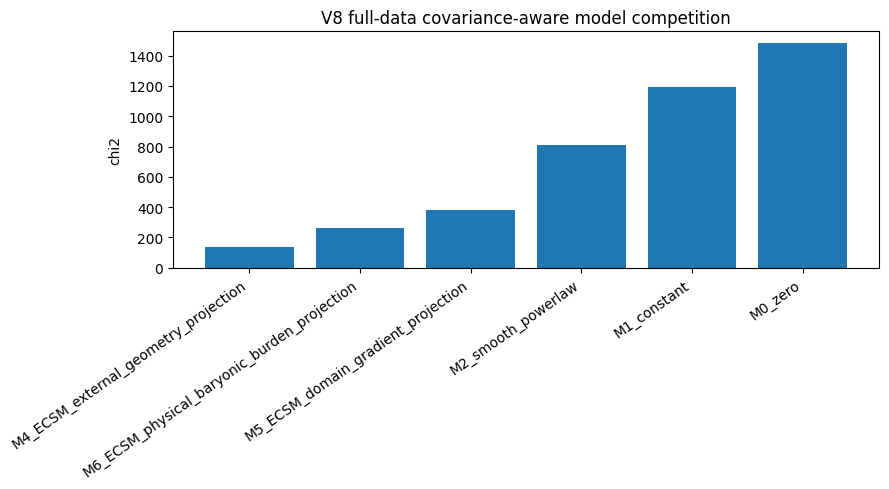

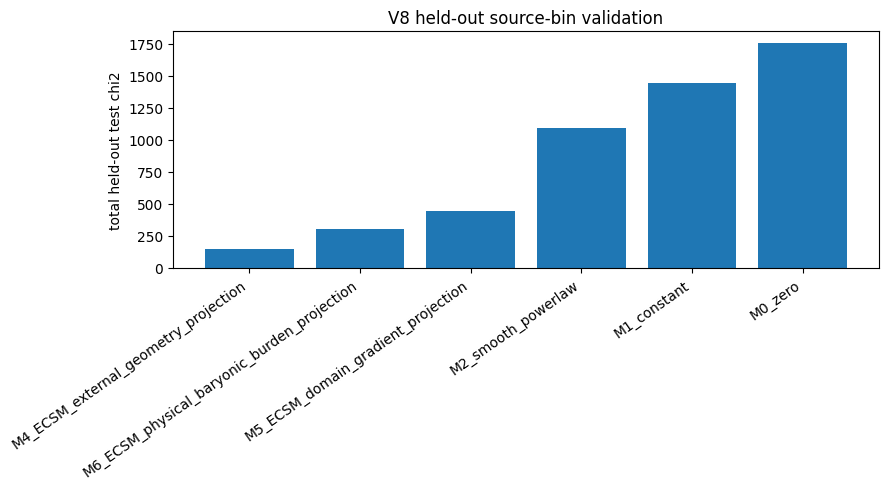

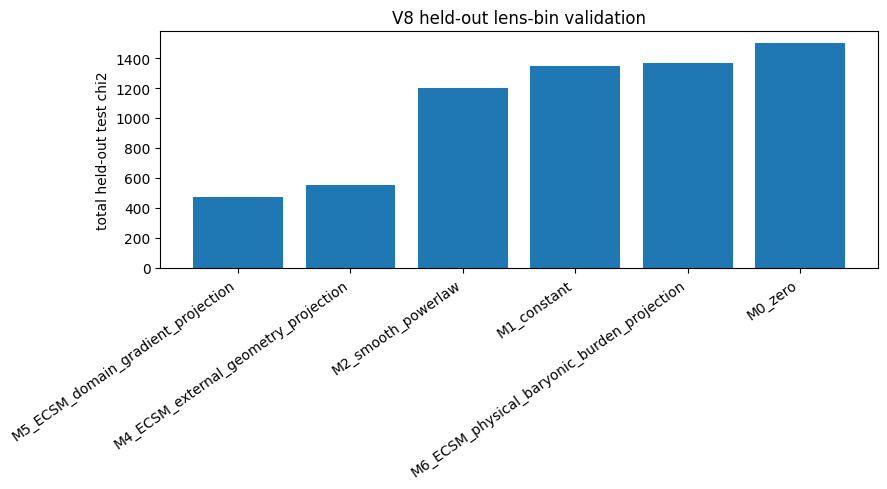

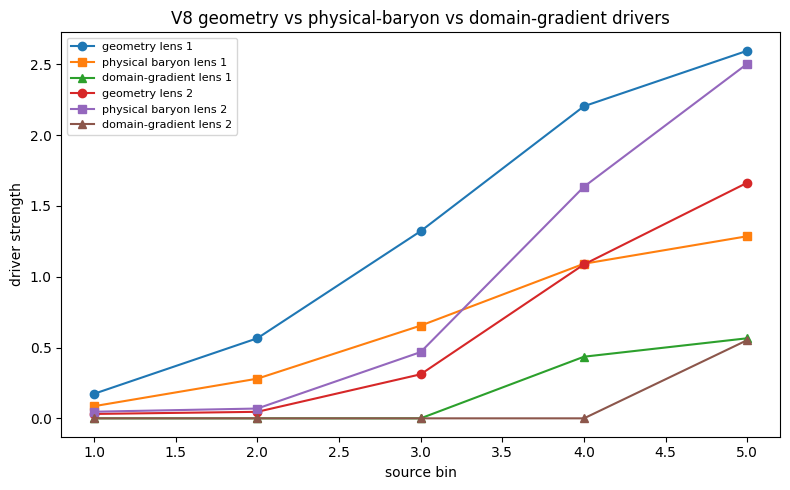

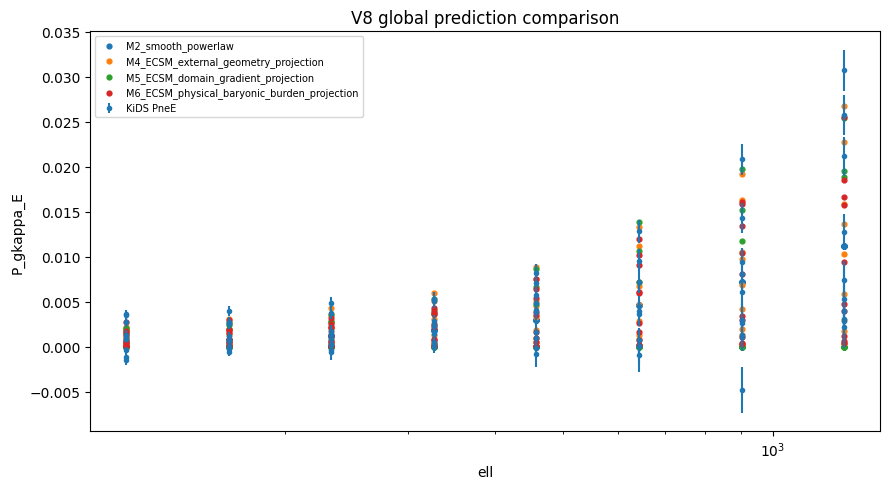

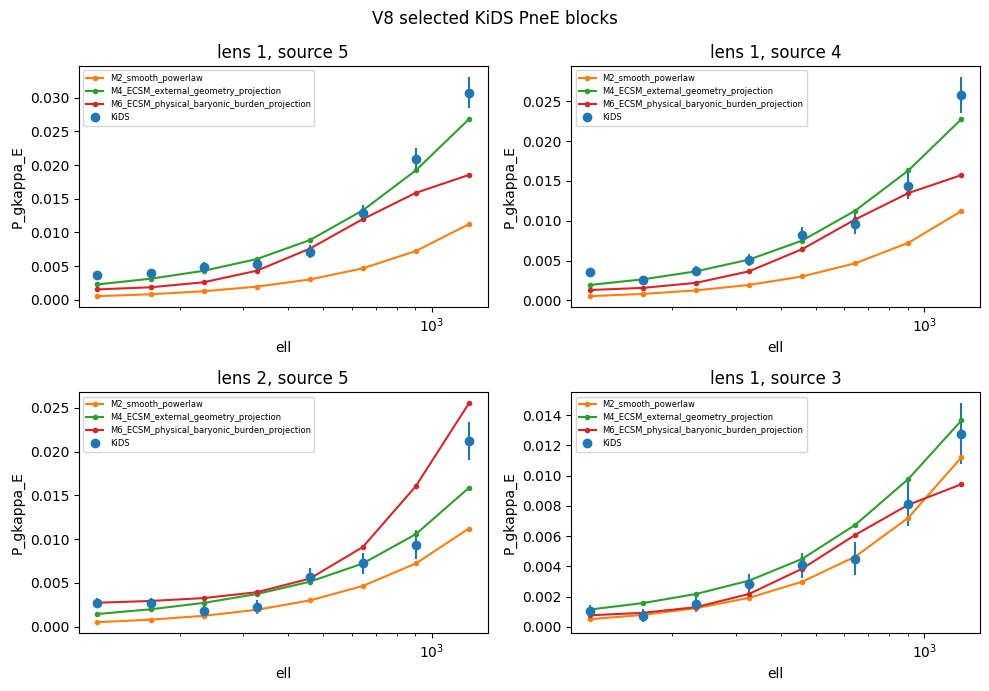

Figures saved in: /content/ecsm_kids_lephare_physical_baryonic_burden_v8_out/figures


In [12]:
# CELL 09 — PREDICTIONS AND FIGURES
banner("CELL 09 — PREDICTIONS AND FIGURES")
pred_df = vec2.copy()
for mn, pred in pred_by_model.items(): pred_df[mn] = pred
pred_df.to_csv(TAB/"v8_predictions.csv", index=False)
display(pred_df.head())

plt.figure(figsize=(9,5)); s = res.sort_values("chi2"); plt.bar(s["model"], s["chi2"]); plt.ylabel("chi2"); plt.title("V8 full-data covariance-aware model competition"); plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.savefig(FIG/"v8_model_competition_chi2.png", dpi=180); plt.show()

def bar_summary(summary, title, fname):
    plt.figure(figsize=(9,5)); ss = summary.sort_values("total_test_chi2"); plt.bar(ss["model"], ss["total_test_chi2"]); plt.ylabel("total held-out test chi2"); plt.title(title); plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.savefig(FIG/fname, dpi=180); plt.show()
bar_summary(source_summary, "V8 held-out source-bin validation", "v8_heldout_sourcebin_validation.png")
bar_summary(lens_summary, "V8 held-out lens-bin validation", "v8_heldout_lensbin_validation.png")

plt.figure(figsize=(8,5))
for lb in sorted(geom.lens_bin.unique()):
    sub = geom[geom.lens_bin == lb].sort_values("source_bin")
    plt.plot(sub["source_bin"], sub["external_geometry_driver"], marker="o", label=f"geometry lens {lb}")
    plt.plot(sub["source_bin"], sub["geometry_burden_driver"], marker="s", label=f"physical baryon lens {lb}")
    plt.plot(sub["source_bin"], sub["domain_gradient_driver"], marker="^", label=f"domain-gradient lens {lb}")
plt.xlabel("source bin"); plt.ylabel("driver strength"); plt.title("V8 geometry vs physical-baryon vs domain-gradient drivers"); plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIG/"v8_driver_comparison.png", dpi=180); plt.show()

plt.figure(figsize=(9,5)); plt.errorbar(pred_df["ell"], pred_df["Pgk_E"], yerr=pred_df["sigma_diag"], fmt="o", ms=3, label="KiDS PneE")
for mn in ["M2_smooth_powerlaw","M4_ECSM_external_geometry_projection","M5_ECSM_domain_gradient_projection","M6_ECSM_physical_baryonic_burden_projection"]:
    plt.scatter(pred_df["ell"], pred_df[mn], s=12, label=mn)
plt.xscale("log"); plt.xlabel("ell"); plt.ylabel("P_gkappa_E"); plt.title("V8 global prediction comparison"); plt.legend(fontsize=7); plt.tight_layout(); plt.savefig(FIG/"v8_global_prediction_comparison.png", dpi=180); plt.show()

blocks = pred_df.groupby(["lens_bin","source_bin"])["Pgk_E"].apply(lambda s: float(np.mean(np.abs(s)))).sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(2,2, figsize=(10,7))
for ax, (lb, sb) in zip(axes.ravel(), blocks):
    sub = pred_df[(pred_df.lens_bin==lb)&(pred_df.source_bin==sb)].sort_values("ell")
    ax.errorbar(sub["ell"], sub["Pgk_E"], yerr=sub["sigma_diag"], fmt="o", label="KiDS")
    for mn in ["M2_smooth_powerlaw","M4_ECSM_external_geometry_projection","M6_ECSM_physical_baryonic_burden_projection"]: ax.plot(sub["ell"], sub[mn], marker=".", label=mn)
    ax.set_xscale("log"); ax.set_title(f"lens {lb}, source {sb}"); ax.set_xlabel("ell"); ax.set_ylabel("P_gkappa_E"); ax.legend(fontsize=6)
plt.suptitle("V8 selected KiDS PneE blocks"); plt.tight_layout(); plt.savefig(FIG/"v8_selected_block_model_comparison.png", dpi=180); plt.show()
print("Figures saved in:", FIG)

In [13]:
# CELL 10 — README / SUMMARY REPORT
banner("CELL 10 — README / SUMMARY REPORT")
best = res.iloc[0].to_dict()
readme = f"""# ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8

## Purpose

This notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector can be modelled using a physical stellar-mass burden derived from the KiDS DR4 bright-galaxy LePhare catalogue.

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `{FITS_PATH.name}`
- Observable: `PneE`
- Data points: {N}
- Lens bins: {vec2.lens_bin.nunique()}
- Source bins: {vec2.source_bin.nunique()}
- Ell range: {vec2.ell.min():.6f} to {vec2.ell.max():.6f}
- Covariance shape: {C.shape}
- Covariance method: {cov_method}

## Physical baryonic catalogue

- Catalogue path: `{LEPHARE_PATH}`
- Redshift column: `{z_col}`
- Stellar mass column: `{mass_col}`
- Usable rows after cuts: {len(leph_small)}
- Burden table: `tables/v8_physical_stellar_mass_burden_by_lens_bin.csv`

## ECSM V8 driver

```text
geometry_burden_driver = lens/source geometry proxy × normalized physical stellar-mass burden
domain_gradient_driver = geometry_burden_driver × domain_boundary_gradient_chi
domain_boundary_gradient_chi = raw_gradient / (1 + raw_gradient)
```

Lens-specific response scales:

```json
{json.dumps(ellB_by_lens, indent=2)}
```

## Full-data competition

{res.to_markdown(index=False)}

## Held-out source-bin validation

{source_summary.to_markdown(index=False)}

## Held-out lens-bin validation

{lens_summary.to_markdown(index=False)}

## Best full-data model

```json
{json.dumps(best, indent=2, default=str)}
```

## Interpretation guardrail

This is stronger than V7 because it uses a real KiDS DR4 LePhare stellar-mass catalogue rather than only an NZ-derived fallback proxy.

It is still not the final full first-principles weak-lensing calculation because it bins stellar mass statistically by lens redshift bin. A final version should connect individual lens positions, angular separations, stellar mass, sizes/scale radii, and source redshift kernels into a proper projected baryonic response integral.
"""
print(readme[:4000])
(OUT/"README.md").write_text(readme)
print("Saved:", OUT/"README.md")


CELL 10 — README / SUMMARY REPORT
# ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8

## Purpose

This notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector can be modelled using a physical stellar-mass burden derived from the KiDS DR4 bright-galaxy LePhare catalogue.

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits`
- Observable: `PneE`
- Data points: 80
- Lens bins: 2
- Source bins: 5
- Ell range: 118.441992 to 1266.442730
- Covariance shape: (80, 80)
- Covariance method: cholesky

## Physical baryonic catalogue

- Catalogue path: `/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits`
- Redshift column: `REDSHIFT`
- Stellar mass column: `MASS_BEST`
- Usable rows after cuts: 1239396
- Burden table: `tables/v8_physical_stellar_mass_burden_by_lens_bin.csv`

## ECSM V8 driver

```text
geometry_burden_driver = lens/s

In [14]:
# CELL 11 — ZIP OUTPUTS AND DOWNLOAD
banner("CELL 11 — ZIP OUTPUTS AND DOWNLOAD")
zip_path = Path("/content/ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_outputs.zip")
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [TAB, FIG]:
        for f in folder.rglob("*"):
            if f.is_file(): z.write(f, f.relative_to(OUT))
    if (OUT/"README.md").exists(): z.write(OUT/"README.md", "README.md")
print("ZIP ready:", zip_path)
print("Size MB:", zip_path.stat().st_size/1e6)
try:
    from google.colab import files, drive
    drive.mount("/content/drive")
    drive_dir = Path("/content/drive/MyDrive/ECSM_KiDS_data")
    drive_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(zip_path, drive_dir/zip_path.name)
    print("Copied to Drive:", drive_dir/zip_path.name)
    files.download(str(zip_path))
except Exception as e:
    print("Colab download/copy skipped or failed:", repr(e))
    print("Download manually from:", zip_path)


CELL 11 — ZIP OUTPUTS AND DOWNLOAD
ZIP ready: /content/ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_outputs.zip
Size MB: 31.332763
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Suggested GitHub filename

```text
ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_DOWNLOAD.ipynb
```

## Expected output ZIP

```text
/content/ECSM_KiDS_LePhare_PhysicalBaryonicBurden_V8_outputs.zip
```